<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/_energy_track/E1_Multivariate_Demand_Lags.ipynb)

# Multivariate Window Method: Electricity Demand
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

The window method again - but now the past isn't just the target's own history. Every hour we know the **weather** and the **clock** too. Build lag columns for demand *and* its covariates, hand the flat table to a dense net, and see what the weather adds on top of "what did demand do last hour?".

*Energy-track version of the room-occupancy lags notebook: same idea, a regression target you can read in megawatts.*

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 8B — Multivariate window method: electricity demand
- Same window method as the temperature notebook, but the covariates come along: temperature, dew point, humidity, and the clock as sin/cos.
- The file is UNSORTED - show it. Train 2018 / test 2019, chronological, no shuffle.
- Lag the target AND the covariates with shift(1..k). Here lagged demand is legitimate (that IS the forecast problem) - contrast with occupancy where lagged occupancy would be cheating.
- Baselines first: mean-only, seasonal naive, persistence. Persistence at one hour ahead is the villain.
- Two dense nets: demand lags only (~47 MW) vs demand + weather lags (~60 MW). The weather HURTS here - 96 lag columns of mostly-noise for a dense net to weigh - and persistence is 129. Say why: one hour ahead, last hour already carries the weather.
- Close with the two plots that keep you honest: the 45-degree scatter AND the time-series overlay.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Bidirectional, Conv1D, MaxPooling1D, Flatten
from keras.callbacks import EarlyStopping
import keras
keras.utils.set_random_seed(5509)   # reproducibility: same numbers every run (CPU exact; a GPU may drift a little)

## Read, sort, split

In [2]:
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/BDL_cleanweather_energy.csv"
df = pd.read_csv(url, parse_dates=["Datetime"])
print("in date order as delivered?", df["Datetime"].is_monotonic_increasing)      # it is NOT - always check
df = df.sort_values("Datetime").set_index("Datetime").ffill()

# two years is plenty for the lecture: train on 2018, test on 2019 - chronological, never shuffled
data  = df.loc["2018-01-01":"2019-12-31", ["BDL_tmpf", "BDL_dwpf", "BDL_relh", "Demand"]].copy()
data["hour_sin"] = np.sin(2*np.pi*data.index.hour/24); data["hour_cos"] = np.cos(2*np.pi*data.index.hour/24)
data["dow_sin"]  = np.sin(2*np.pi*data.index.dayofweek/7); data["dow_cos"] = np.cos(2*np.pi*data.index.dayofweek/7)
data = data[["BDL_tmpf", "BDL_dwpf", "BDL_relh", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "Demand"]]   # Demand LAST
train, test = data.loc[:"2018-12-31"], data.loc["2019-01-01":]
print("train:", train.shape, "| test:", test.shape)
data.head()

in date order as delivered? False
train: (8760, 8) | test: (8760, 8)


,BDL_tmpf,BDL_dwpf,BDL_relh,hour_sin,hour_cos,dow_sin,dow_cos,Demand
Datetime,,,,,,,,
2018-01-01 00:00:00,1.9,0.0,56.85,0.000000,1.000000,0.0,1.0,3867.09
2018-01-01 01:00:00,0.0,0.0,62.12,0.258819,0.965926,0.0,1.0,3749.96
2018-01-01 02:00:00,0.0,0.0,61.38,0.500000,0.866025,0.0,1.0,3673.50
2018-01-01 03:00:00,0.0,0.0,71.11,0.707107,0.707107,0.0,1.0,3646.25
2018-01-01 04:00:00,0.0,0.0,64.21,0.866025,0.500000,0.0,1.0,3660.86


## Baselines first

In [3]:
y = test["Demand"]
baselines = pd.Series({
    "mean-only":                       mean_absolute_error(y, np.full(len(y), train["Demand"].mean())),
    "seasonal naive (same hour yday)": mean_absolute_error(y.iloc[24:], y.shift(24).iloc[24:]),
    "persistence (last hour)":         mean_absolute_error(y.iloc[1:],  y.shift(1).iloc[1:]),
}, name="test MAE (MW)").round(1)
baselines

mean-only                          563.3
seasonal naive (same hour yday)    227.1
persistence (last hour)            129.0
Name: test MAE (MW), dtype: float64

## Build the lag table

`shift(k)` moves a column down `k` rows, so row *t* holds the value from *k* hours ago. Do it for the target **and** the covariates, drop the rows with no history, and the sequence problem has become a flat table any model can eat.

In [4]:
def make_lags(d, cols, n_lags):
    out = pd.DataFrame(index=d.index)
    for c in cols:
        for k in range(1, n_lags + 1):
            out[f"{c}_lag{k}"] = d[c].shift(k)
    out["target"] = d["Demand"]                      # what we predict: demand NOW, from the past k hours
    return out.dropna()

n_lags = 24
lag_demand = make_lags(data, ["Demand"], n_lags)                                     # 24 columns
lag_all    = make_lags(data, ["Demand", "BDL_tmpf", "BDL_dwpf", "BDL_relh"], n_lags)   # 96 columns
lag_all = lag_all.join(data[["hour_sin", "hour_cos", "dow_sin", "dow_cos"]])          # the clock needs no lag - we know what time it is
lag_all = lag_all[[c for c in lag_all.columns if c != "target"] + ["target"]]
print(lag_demand.shape, lag_all.shape)
lag_all.head(3)

(17496, 25) (17496, 101)


,Demand_lag1,Demand_lag2,Demand_lag3,Demand_lag4,Demand_lag5,Demand_lag6,Demand_lag7,Demand_lag8,Demand_lag9,Demand_lag10,...,BDL_relh_lag20,BDL_relh_lag21,BDL_relh_lag22,BDL_relh_lag23,BDL_relh_lag24,hour_sin,hour_cos,dow_sin,dow_cos,target
Datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-02 00:00:00,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,4325.71,4259.30,...,64.21,71.11,61.38,62.12,56.85,0.000000,1.000000,0.781831,0.62349,3733.57
2018-01-02 01:00:00,3733.57,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,4325.71,...,61.08,64.21,71.11,61.38,62.12,0.258819,0.965926,0.781831,0.62349,3641.62
2018-01-02 02:00:00,3641.62,3733.57,3900.18,4166.84,4476.18,4697.43,4831.56,4882.31,4900.78,4594.62,...,60.91,61.08,64.21,71.11,61.38,0.500000,0.866025,0.781831,0.62349,3594.10


## Dense net on the lags: demand only, then demand + weather

Scale on train only, fit, score in MW. Same network twice - the only difference is what it gets to see.

In [5]:
def fit_dense(tab, name):
    tr, te = tab.loc[:"2018-12-31"], tab.loc["2019-01-01":]
    scX = MinMaxScaler().fit(tr.iloc[:, :-1]); scy = MinMaxScaler().fit(tr[["target"]])
    Xtr, Xte = scX.transform(tr.iloc[:, :-1]), scX.transform(te.iloc[:, :-1])
    ytr = scy.transform(tr[["target"]]).ravel()
    m = Sequential([Dense(64, activation="relu", input_shape=(Xtr.shape[1],)), Dense(32, activation="relu"), Dense(1)])
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    m.fit(Xtr, ytr, epochs=40, batch_size=64, validation_split=0.2, callbacks=[es], verbose=0)
    pred = scy.inverse_transform(m.predict(Xte, verbose=0)).ravel()
    mae = mean_absolute_error(te["target"], pred)
    print(f"{name:28s} params: {m.count_params():6d}   test MAE: {mae:.1f} MW")
    return m, pred, te["target"].values

es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=0)
dense_d, pred_d, truth = fit_dense(lag_demand, "demand lags only")
dense_a, pred_a, _     = fit_dense(lag_all,    "demand + weather + clock")
print("\npersistence baseline:", baselines.iloc[2], "MW")

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


demand lags only             params:   3713   test MAE: 47.1 MW


C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


demand + weather + clock     params:   8577   test MAE: 60.0 MW

persistence baseline: 129.0 MW


## The two honest plots

A 45-degree scatter can look perfect for a model that just repeats last hour. The time-series overlay shows whether it *leads* or *lags* reality.

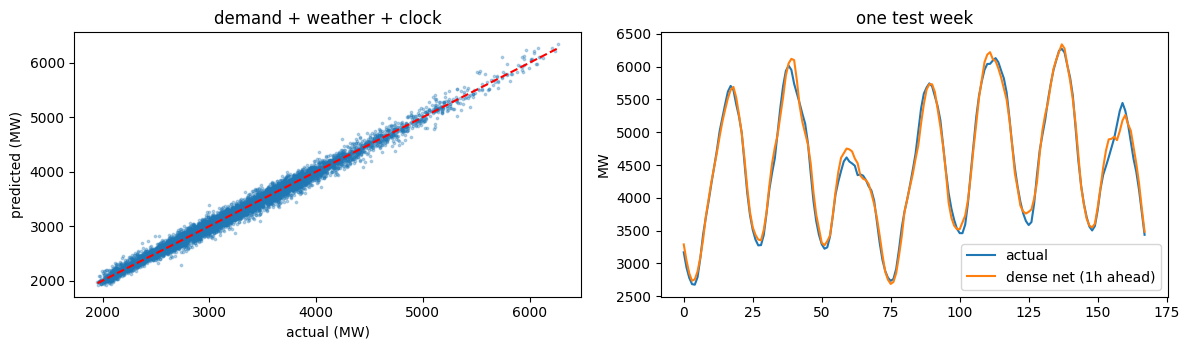

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].scatter(truth, pred_a, s=3, alpha=0.3); ax[0].plot([truth.min(), truth.max()], [truth.min(), truth.max()], "r--")
ax[0].set_xlabel("actual (MW)"); ax[0].set_ylabel("predicted (MW)"); ax[0].set_title("demand + weather + clock")
i0 = 24*7*28
ax[1].plot(truth[i0:i0+24*7], label="actual"); ax[1].plot(pred_a[i0:i0+24*7], label="dense net (1h ahead)")
ax[1].set_title("one test week"); ax[1].set_ylabel("MW"); ax[1].legend(); plt.tight_layout(); plt.show()

## Save the model and use it again

In [7]:
dense_a.save('E1_Multivariate_Demand_Lags.keras')
reloaded = load_model('E1_Multivariate_Demand_Lags.keras')
tr = lag_all.loc[:"2018-12-31"]; scX = MinMaxScaler().fit(tr.iloc[:, :-1])
Xte = scX.transform(lag_all.loc["2019-01-01":].iloc[:5, :-1])
print("reloaded model reproduces the predictions:", np.allclose(dense_a.predict(Xte, verbose=0), reloaded.predict(Xte, verbose=0)))

reloaded model reproduces the predictions: True


## On your own

- Try `n_lags = 6` and `n_lags = 168` (a week). Does more history help a dense net, or just add parameters?
- Drop the demand lags entirely: weather + clock only. How bad is a forecast that never looks at demand?
- Replace the target with **demand 24 hours from now** (`shift(-24)`). Persistence stops being cheap - who wins now?